In [12]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
df=sns.load_dataset("tips")

df1=df

In [14]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [16]:
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [17]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


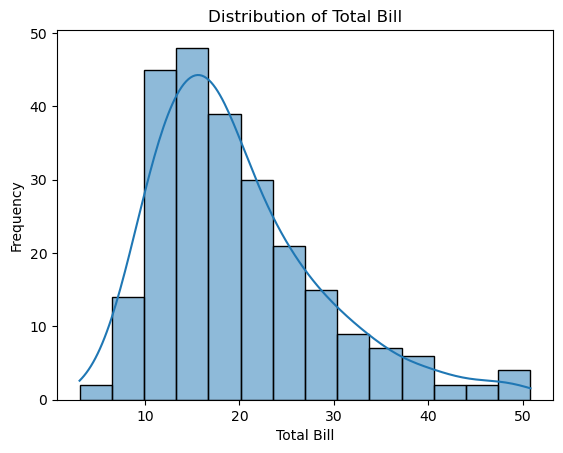

In [18]:
sns.histplot(df["total_bill"], kde=True)

plt.title("Distribution of Total Bill")
plt.xlabel("Total Bill")
plt.ylabel("Frequency")

plt.show()

### Most Bills are between 10 and 20 dollars and it shows right skewed distribution

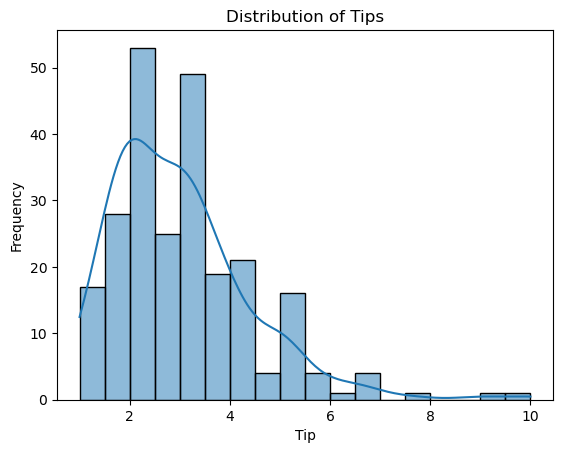

In [19]:
sns.histplot(df["tip"], kde=True)

plt.title("Distribution of Tips")
plt.xlabel("Tip")
plt.ylabel("Frequency")

plt.show()

### Most tips are between 2 and 4
#### Few very large tips

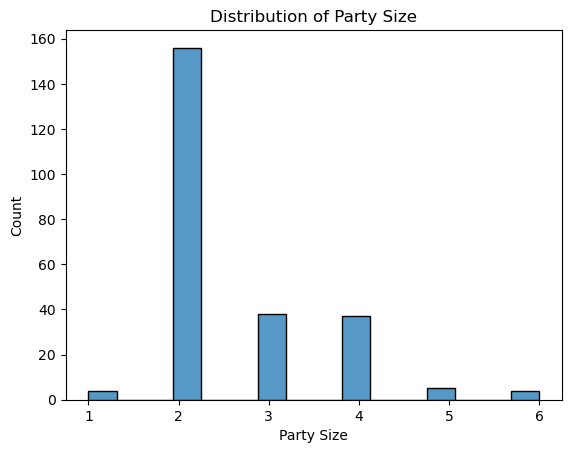

In [20]:
sns.histplot(df["size"], kde=False)

plt.title("Distribution of Party Size")
plt.xlabel("Party Size")
plt.ylabel("Count")

plt.show()

### Most tables have 2 or 3 people

In [21]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


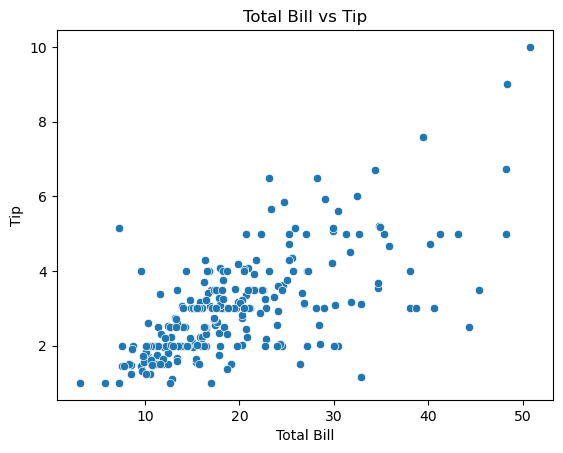

In [22]:
sns.scatterplot(data=df, x="total_bill", y="tip")

plt.title("Total Bill vs Tip")
plt.xlabel("Total Bill")
plt.ylabel("Tip")

plt.show()

### Shows Positive Relationship

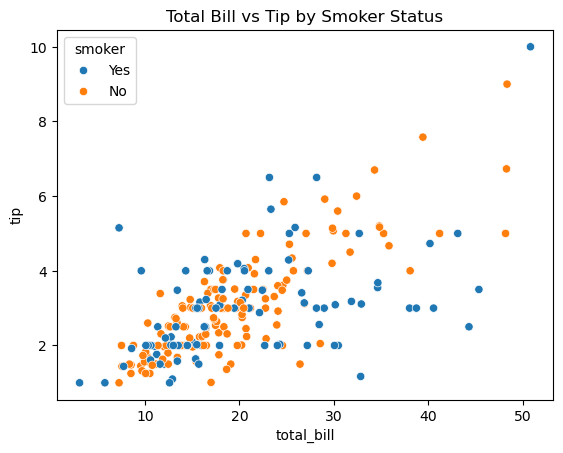

In [23]:
sns.scatterplot(data=df, x="total_bill", y="tip", hue="smoker")

plt.title("Total Bill vs Tip by Smoker Status")

plt.show()

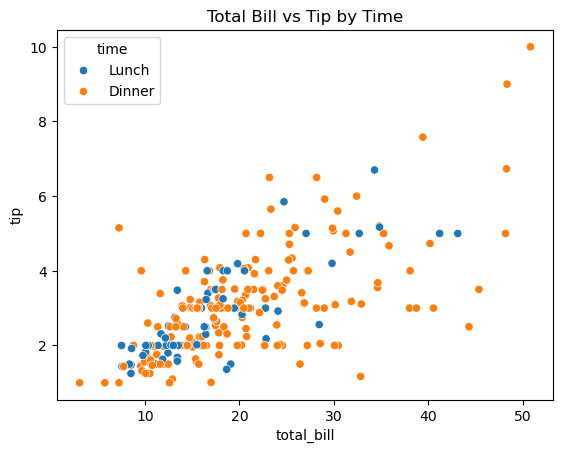

In [25]:
sns.scatterplot(data=df, x="total_bill", y="tip", hue="time")

plt.title("Total Bill vs Tip by Time")

plt.show()

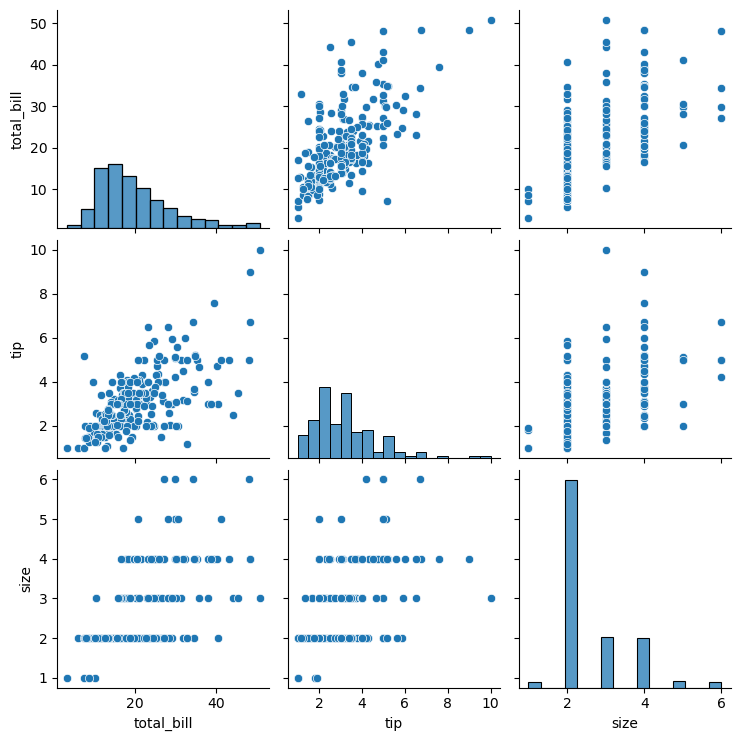

In [26]:
sns.pairplot(df)

plt.show()

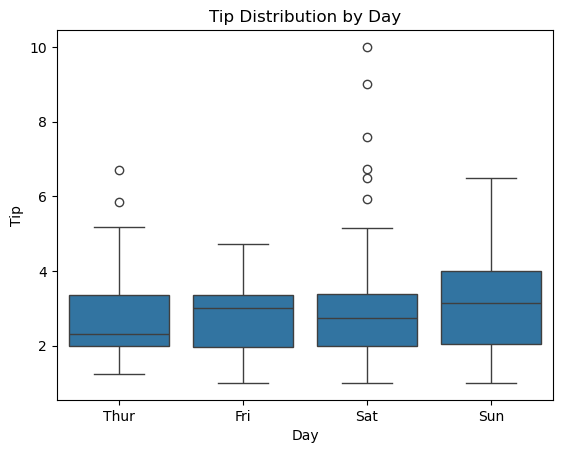

In [27]:
sns.boxplot(data=df, x="day", y="tip")

plt.title("Tip Distribution by Day")
plt.xlabel("Day")
plt.ylabel("Tip")

plt.show()

### Weekend tips (Sat, Sun) are usually higher.

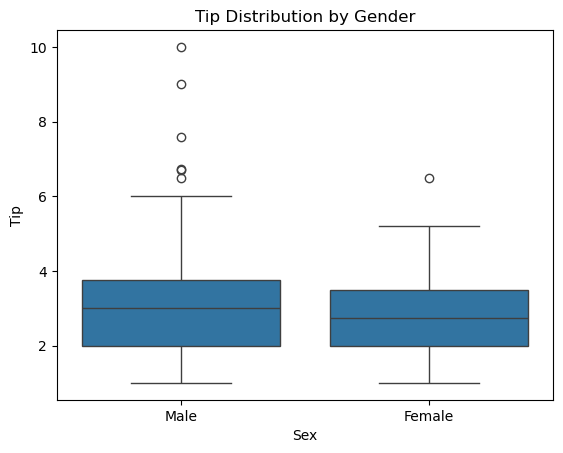

In [28]:
sns.boxplot(data=df, x="sex", y="tip")

plt.title("Tip Distribution by Gender")
plt.xlabel("Sex")
plt.ylabel("Tip")

plt.show()

#### males appear to give slightly higher tips but it may also be because their bills are larger

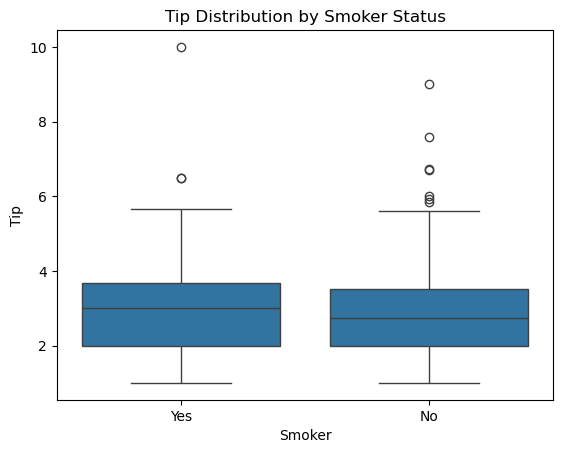

In [29]:
sns.boxplot(data=df, x="smoker", y="tip")

plt.title("Tip Distribution by Smoker Status")
plt.xlabel("Smoker")
plt.ylabel("Tip")

plt.show()

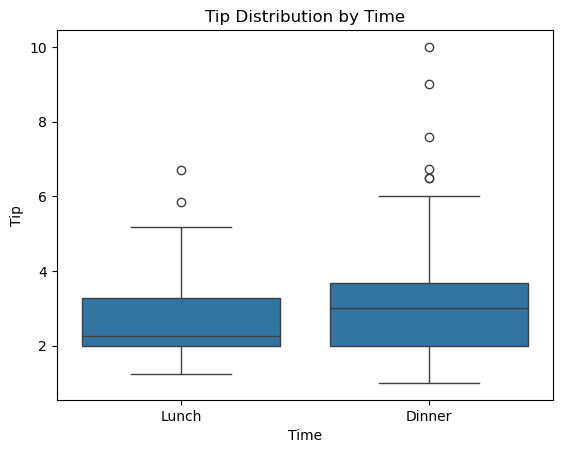

In [30]:
sns.boxplot(data=df, x="time", y="tip")

plt.title("Tip Distribution by Time")
plt.xlabel("Time")
plt.ylabel("Tip")

plt.show()

### dinner bills are usually larger.

In [32]:
corr = df.corr(numeric_only=True)

print(corr)

            total_bill       tip      size
total_bill    1.000000  0.675734  0.598315
tip           0.675734  1.000000  0.489299
size          0.598315  0.489299  1.000000


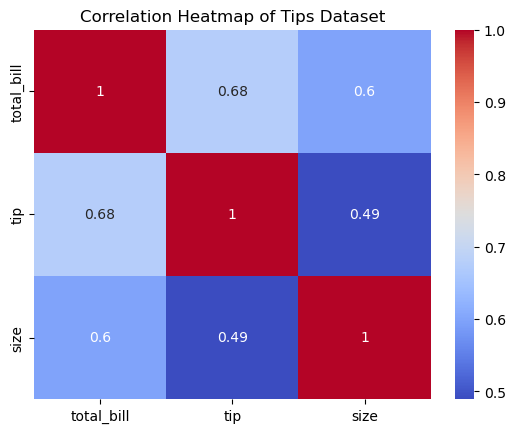

In [33]:
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap of Tips Dataset")

plt.show()

In [34]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [35]:
X = df[["sex","day","time"]]
y = df["smoker"]

In [36]:
X = pd.get_dummies(X, drop_first=True)

In [37]:
X.head()

,sex_Female,day_Fri,day_Sat,day_Sun,time_Dinner
0,True,False,False,True,True
1,False,False,False,True,True
2,False,False,False,True,True
3,False,False,False,True,True
4,True,False,False,True,True


In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [39]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()

model.fit(X_train, y_train)

GaussianNB()

In [40]:
y_pred = model.predict(X_test)

In [41]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.673469387755102

Classification Report:

              precision    recall  f1-score   support

          No       0.66      1.00      0.79        31
         Yes       1.00      0.11      0.20        18

    accuracy                           0.67        49
   macro avg       0.83      0.56      0.50        49
weighted avg       0.78      0.67      0.58        49


Confusion Matrix:

[[31  0]
 [16  2]]
